**Description:**

Here

# Imports

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns
import numpy as np

# V1

In [15]:
v1_df = pd.read_csv('../media/v1/FINAL_LBPs_BalancerV1.csv')
v1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   pool_id                      96 non-null     object 
 1   launch_date                  96 non-null     object 
 2   duration_h                   96 non-null     float64
 3   start_weight_proj            96 non-null     float64
 4   end_weight_proj              96 non-null     float64
 5   weight_slope                 96 non-null     float64
 6   total_swaps                  96 non-null     int64  
 7   unique_users                 96 non-null     int64  
 8   swaps_per_hour               96 non-null     float64
 9   peak_activity_time           96 non-null     float64
 10  price_efficiency             96 non-null     float64
 11  max_drawdown                 96 non-null     float64
 12  buy_pressure_avg             96 non-null     float64
 13  is_dead_pool          

## Data distribution and cleaning

--- 1. Checking Class Balance ---


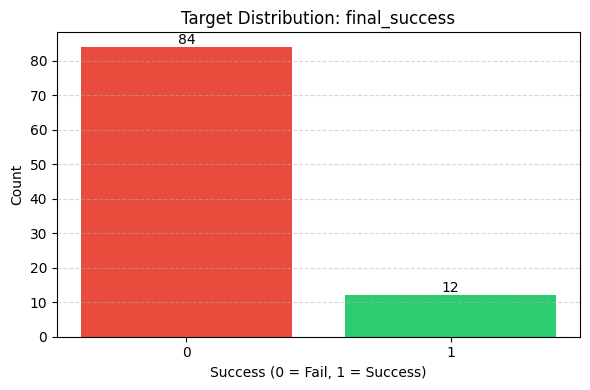

--- 2. Checking Numerical Distributions ---


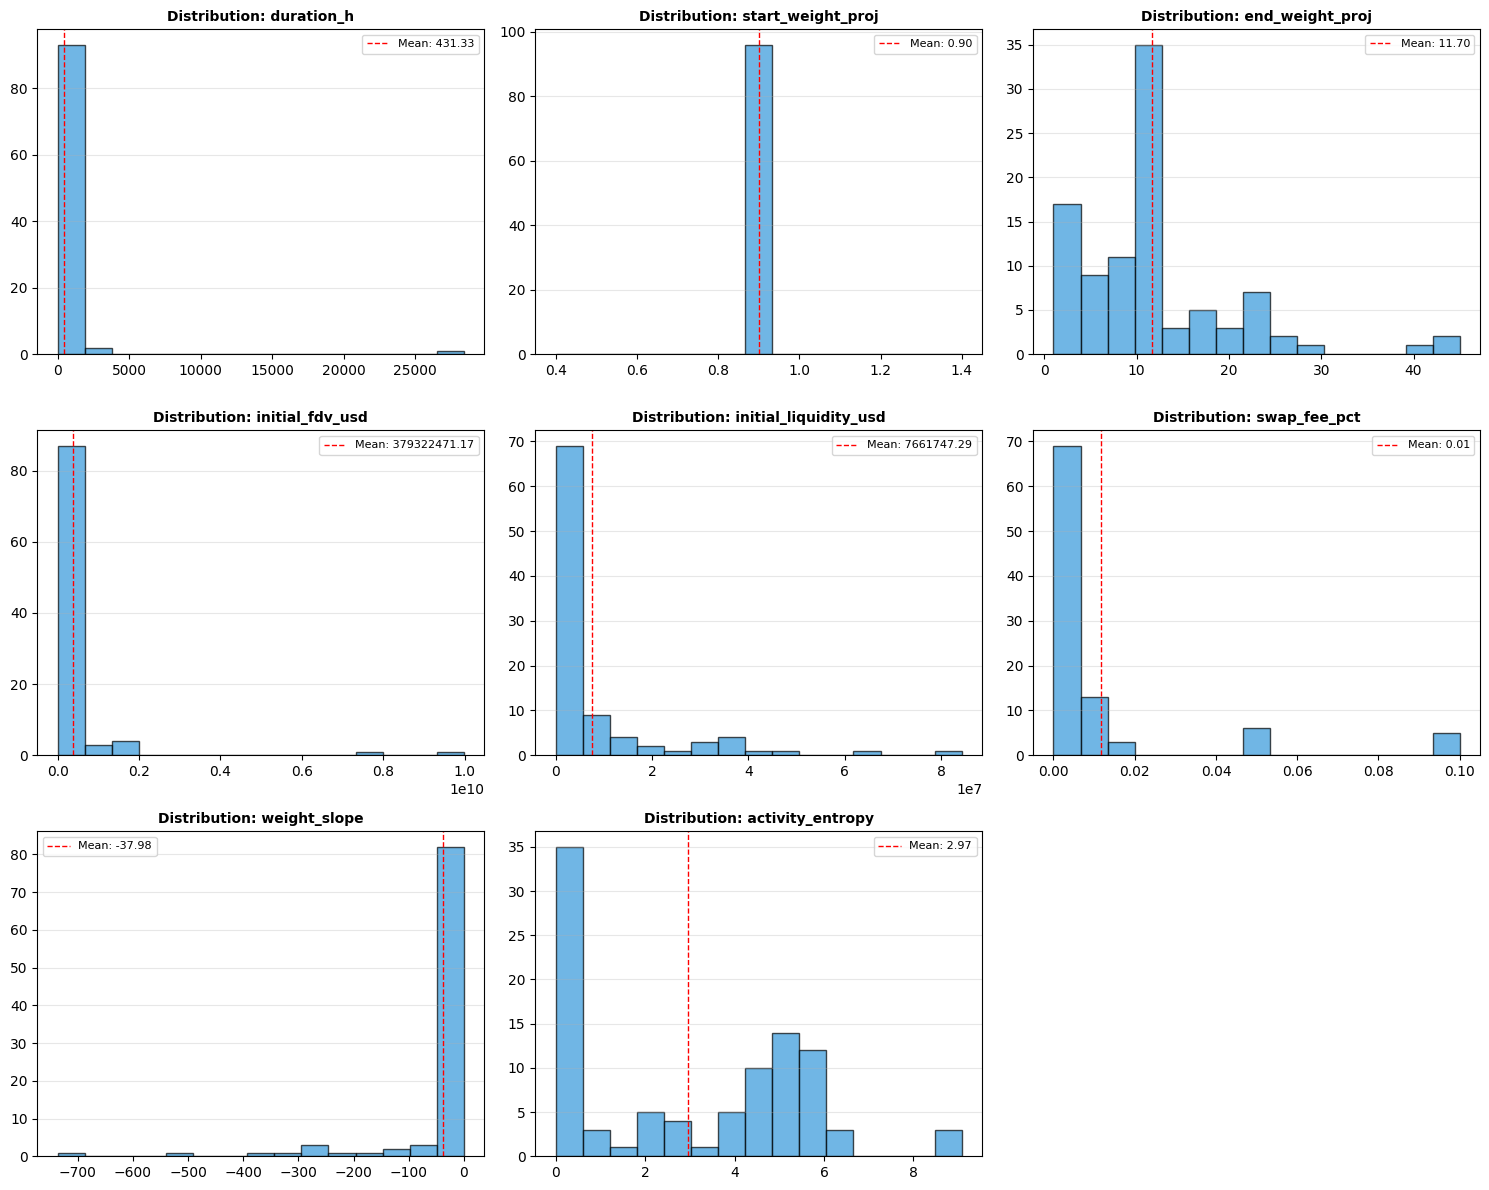

--- 3. Checking Feature Separation (Boxplots) ---


C:\Users\kaiqu\AppData\Local\Temp\ipykernel_20416\1874416690.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1], labels=['Fail (0)', 'Success (1)'],
C:\Users\kaiqu\AppData\Local\Temp\ipykernel_20416\1874416690.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1], labels=['Fail (0)', 'Success (1)'],
C:\Users\kaiqu\AppData\Local\Temp\ipykernel_20416\1874416690.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1], labels=['Fail (0)', 'Success (1)'],
C:\Users\kaiqu\AppData\Local\Temp\ipykernel_20416\1874416690.py:79: Matpl

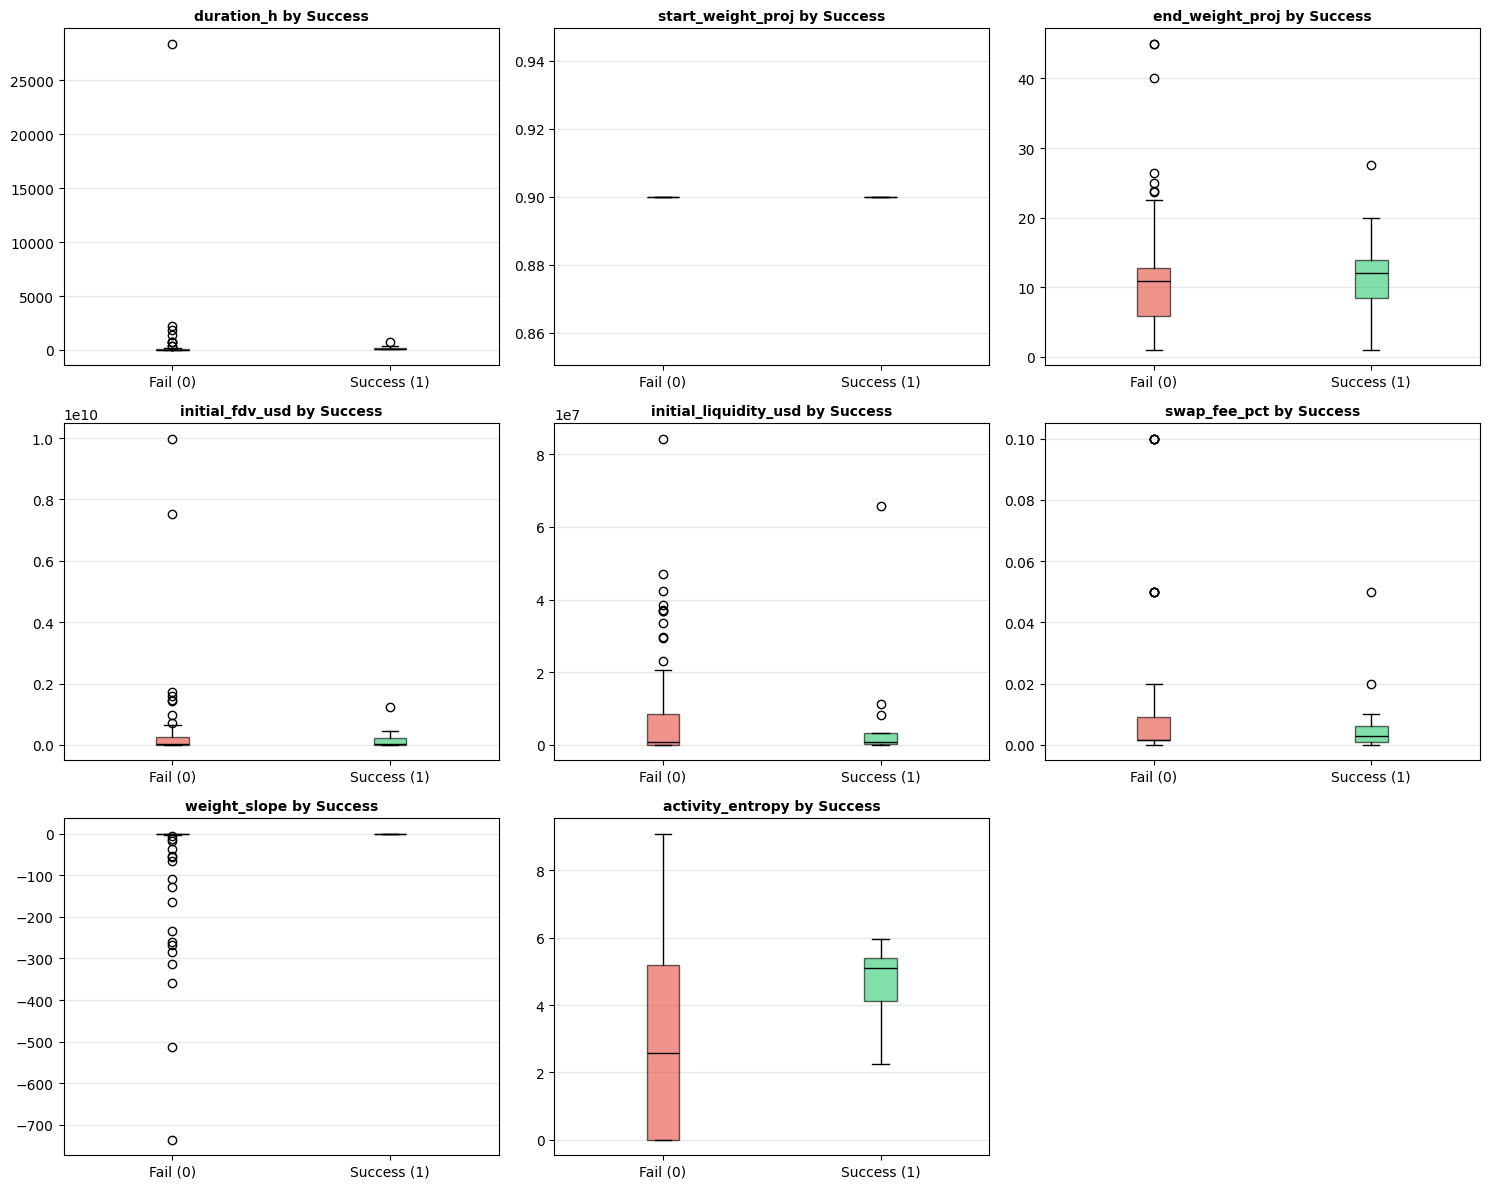

In [18]:
numerical_features = [
    'duration_h', 'start_weight_proj', 'end_weight_proj', 
    'initial_fdv_usd', 'initial_liquidity_usd', 'swap_fee_pct',
    'weight_slope', 'activity_entropy'
]


def plot_target_balance(df, target_col='final_success'):
    counts = df[target_col].value_counts()
    
    plt.figure(figsize=(6, 4))
    bars = plt.bar(counts.index.astype(str), counts.values, color=['#e74c3c', '#2ecc71'])
    
    plt.title(f'Target Distribution: {target_col}', fontsize=12)
    plt.ylabel('Count')
    plt.xlabel('Success (0 = Fail, 1 = Success)')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Add count labels on top
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()


def plot_numerical_distributions(df, features):
    n_cols = 3
    n_rows = math.ceil(len(features) / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(features):
        ax = axes[i]
        
        # Plot histogram
        ax.hist(df[col], bins=15, color='#3498db', edgecolor='black', alpha=0.7)
        
        # Add mean line
        mean_val = df[col].mean()
        ax.axvline(mean_val, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_val:.2f}')
        
        ax.set_title(f'Distribution: {col}', fontsize=10, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)

    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()


def plot_feature_vs_success(df, features, target='final_success'):
    n_cols = 3
    n_rows = math.ceil(len(features) / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(features):
        ax = axes[i]
        
        # Prepare data for boxplot
        data_0 = df[df[target] == 0][col]
        data_1 = df[df[target] == 1][col]
        
        # Create boxplot
        bp = ax.boxplot([data_0, data_1], labels=['Fail (0)', 'Success (1)'], 
                        patch_artist=True, medianprops=dict(color="black"))
        
        # Color coding
        colors = ['#e74c3c', '#2ecc71']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
            
        ax.set_title(f'{col} by Success', fontsize=10, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)

    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()


plt.style.use('fast') 

print("--- 1. Checking Class Balance ---")
plot_target_balance(v1_df)

print("--- 2. Checking Numerical Distributions ---")
plot_numerical_distributions(v1_df, numerical_features)

print("--- 3. Checking Feature Separation (Boxplots) ---")
plot_feature_vs_success(v1_df, numerical_features)

--- 1. Checking Correlations ---


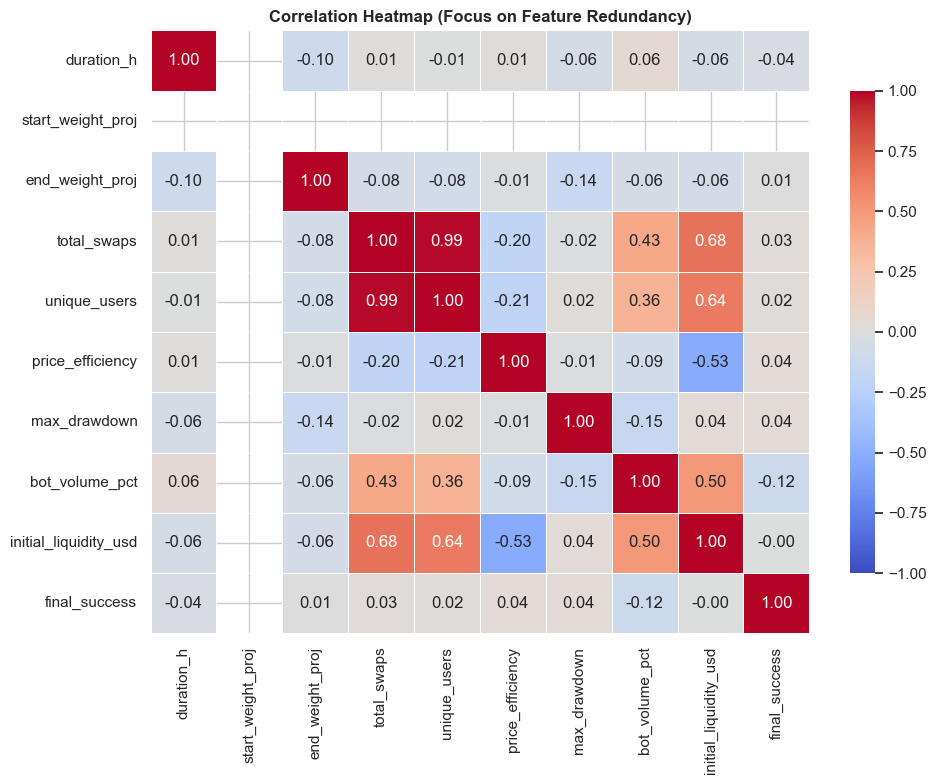

--- 2. Checking Bot Influence ---


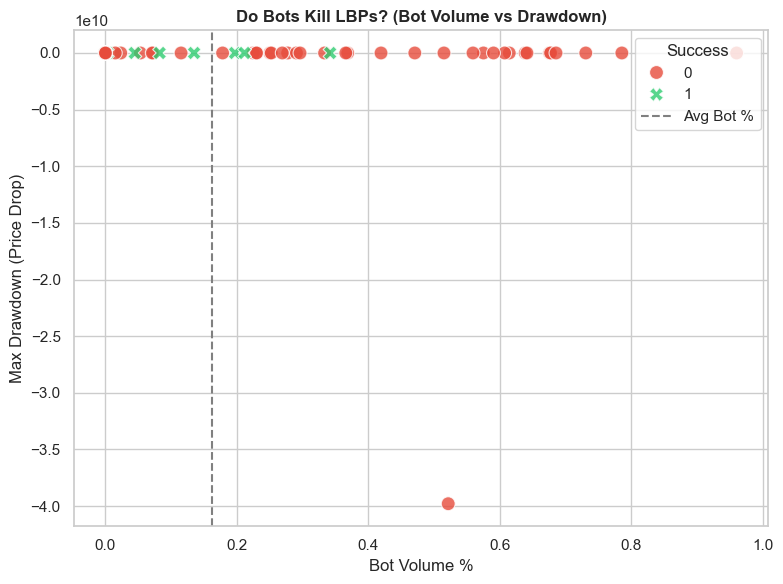

--- 3. Checking Build Parameters ---


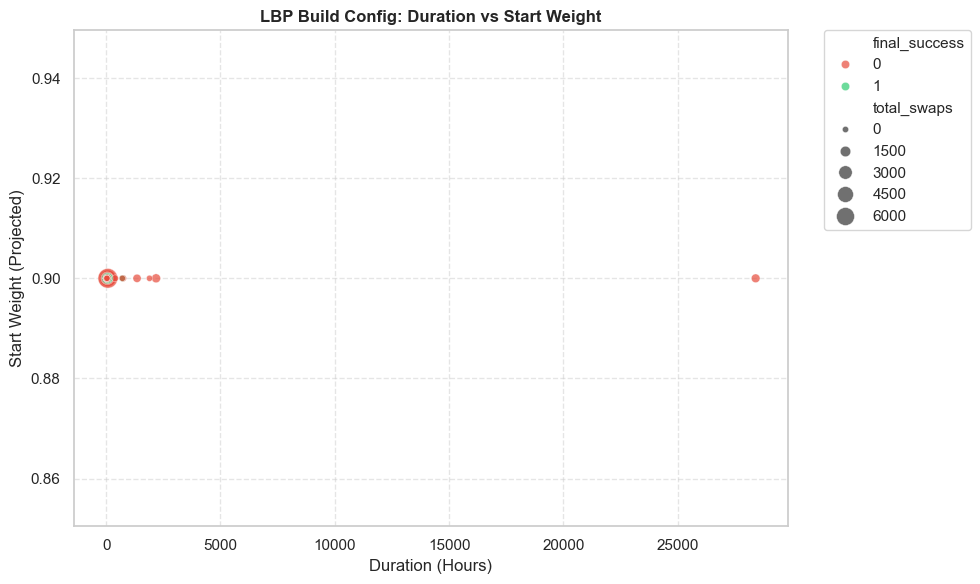

In [20]:
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. Correlation Matrix (to filter redundant features)
# ---------------------------------------------------------
def plot_correlation_matrix(df):
    # Select only numerical columns relevant to metrics
    cols_to_check = [
        'duration_h', 'start_weight_proj', 'end_weight_proj', 
        'total_swaps', 'unique_users', 'price_efficiency', 
        'max_drawdown', 'bot_volume_pct', 'initial_liquidity_usd',
        'final_success' # Important to see what correlates with target
    ]
    
    corr = df[cols_to_check].corr()

    plt.figure(figsize=(10, 8))
    # Heatmap with masking for the upper triangle (cleaner look)
    mask =  corr.where(abs(corr) > 0.3, 0) # Only show relevant correlations
    
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', 
                vmin=-1, vmax=1, center=0, linewidths=0.5,
                cbar_kws={"shrink": .8})
    
    plt.title('Correlation Heatmap (Focus on Feature Redundancy)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 2. Bot Impact Analysis (Scatter Plot)
# ---------------------------------------------------------
def plot_bot_impact(df):
    plt.figure(figsize=(8, 6))
    
    # Scatter: Bot Volume vs Max Drawdown, colored by Success
    sns.scatterplot(
        data=df, 
        x='bot_volume_pct', 
        y='max_drawdown', 
        hue='final_success', 
        style='final_success',
        palette={0: '#e74c3c', 1: '#2ecc71'},
        s=100, # dot size
        alpha=0.8
    )
    
    plt.title('Do Bots Kill LBPs? (Bot Volume vs Drawdown)', fontsize=12, fontweight='bold')
    plt.xlabel('Bot Volume %')
    plt.ylabel('Max Drawdown (Price Drop)')
    plt.axvline(x=df['bot_volume_pct'].mean(), color='gray', linestyle='--', label='Avg Bot %')
    plt.legend(title='Success', loc='upper right')
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 3. Configuration "Sweet Spot" (3D-like 2D plot)
# ---------------------------------------------------------
def plot_config_landscape(df):
    plt.figure(figsize=(10, 6))
    
    # We want to see: Duration vs Liquidity vs Success
    # Size of bubble = Total Volume (or Swaps) to show activity depth
    
    scatter = sns.scatterplot(
        data=df, 
        x='duration_h', 
        y='start_weight_proj', 
        hue='final_success',
        size='total_swaps', # Bubble size based on activity
        sizes=(20, 200),
        palette={0: '#e74c3c', 1: '#2ecc71'},
        alpha=0.7
    )
    
    plt.title('LBP Build Config: Duration vs Start Weight', fontsize=12, fontweight='bold')
    plt.xlabel('Duration (Hours)')
    plt.ylabel('Start Weight (Projected)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# Execution
# ---------------------------------------------------------
print("--- 1. Checking Correlations ---")
plot_correlation_matrix(v1_df)

print("--- 2. Checking Bot Influence ---")
plot_bot_impact(v1_df)

print("--- 3. Checking Build Parameters ---")
plot_config_landscape(v1_df)

In [ ]:
def strict_clean_data(df):
    df_clean = df.copy()
    
    # ---------------------------------------------------------
    # 1. SANITY CHECK (The "Physics" Layer)
    # ---------------------------------------------------------
    # Remove rows that are physically impossible before doing stats.
    
    # Duration must be positive
    rows_before = df_clean.shape[0] 
    df_clean = df_clean[df_clean['duration_h'] > 0]
    print(f"Rows after removing non-positive durations: {len(df_clean)} (Removed {rows_before - len(df_clean)})")
    
    # Money/Weights must be positive for Log Transform to work
    # We use a small epsilon (1e-9) to avoid log(0) issues just in case
    rows_before = df_clean.shape[0] 
    df_clean = df_clean[df_clean['initial_fdv_usd'] > 0]
    print(f"Rows after removing non-positive FDV: {len(df_clean)} (Removed {rows_before - len(df_clean)})")

    rows_before = df_clean.shape[0] 
    df_clean = df_clean[df_clean['initial_liquidity_usd'] > 0]
    
    
    print(f"--- 1. Sanity Check (Physical Rules) ---")
    print(f"Rows after removing impossible values (negatives/zeros): {len(df_clean)}")

    # ---------------------------------------------------------
    # 2. LOG TRANSFORMATION
    # ---------------------------------------------------------
    # Now it is safe to apply log because all values are > 0
    money_cols = ['initial_fdv_usd', 'initial_liquidity_usd', 'start_weight_proj']
    
    for col in money_cols:
        df_clean[f'log_{col}'] = np.log1p(df_clean[col])

    # ---------------------------------------------------------
    # 3. STATISTICAL CLEANING (IQR on specific columns)
    # ---------------------------------------------------------
    # Now we remove statistical outliers
    cols_to_filter = ['duration_h', 'weight_slope', 'max_drawdown', 'bot_volume_pct']
    threshold = 3.0 
    
    indices_to_drop = set()
    
    print(f"\n--- 2. Statistical Cleaning (Threshold: {threshold}) ---")
    for col in cols_to_filter:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - (threshold * IQR)
        upper_bound = Q3 + (threshold * IQR)
        
        # Enforce Logical Lower Bounds for specific columns
        if col == 'duration_h': lower_bound = max(lower_bound, 0) # Duration can't be < 0
        
        outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
        
        if len(outliers) > 0:
            print(f"Column '{col}': Found {len(outliers)} outliers")
            indices_to_drop.update(outliers.index)
            
    df_final = df_clean.drop(index=list(indices_to_drop))
    
    print("-" * 40)
    print(f"Original Rows: {len(df)}")
    print(f"Final Rows:    {len(df_final)}")
    print("-" * 40)
    
    return df_final

# Run the strict cleaning
v1_df_ready = strict_clean_data(v1_df)

# Final check
print("\nMin Duration:", v1_df_ready['duration_h'].min())
print("Min Liquidity:", v1_df_ready['initial_liquidity_usd'].min())

--- 1. Sanity Check (Physical Rules) ---
Rows after removing impossible values (negatives/zeros): 75

--- 2. Statistical Cleaning (Threshold: 3.0) ---
Column 'duration_h': Found 11 outliers
Column 'weight_slope': Found 14 outliers
Column 'max_drawdown': Found 13 outliers
----------------------------------------
Original Rows: 96
Final Rows:    42
----------------------------------------

Min Duration: 0.4175
Min Liquidity: 55.0


## Recreate analysis after data cleaning

--- 1. Checking Class Balance ---


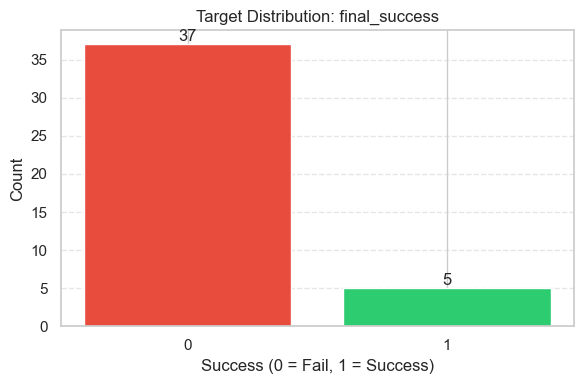

--- 2. Checking Numerical Distributions ---


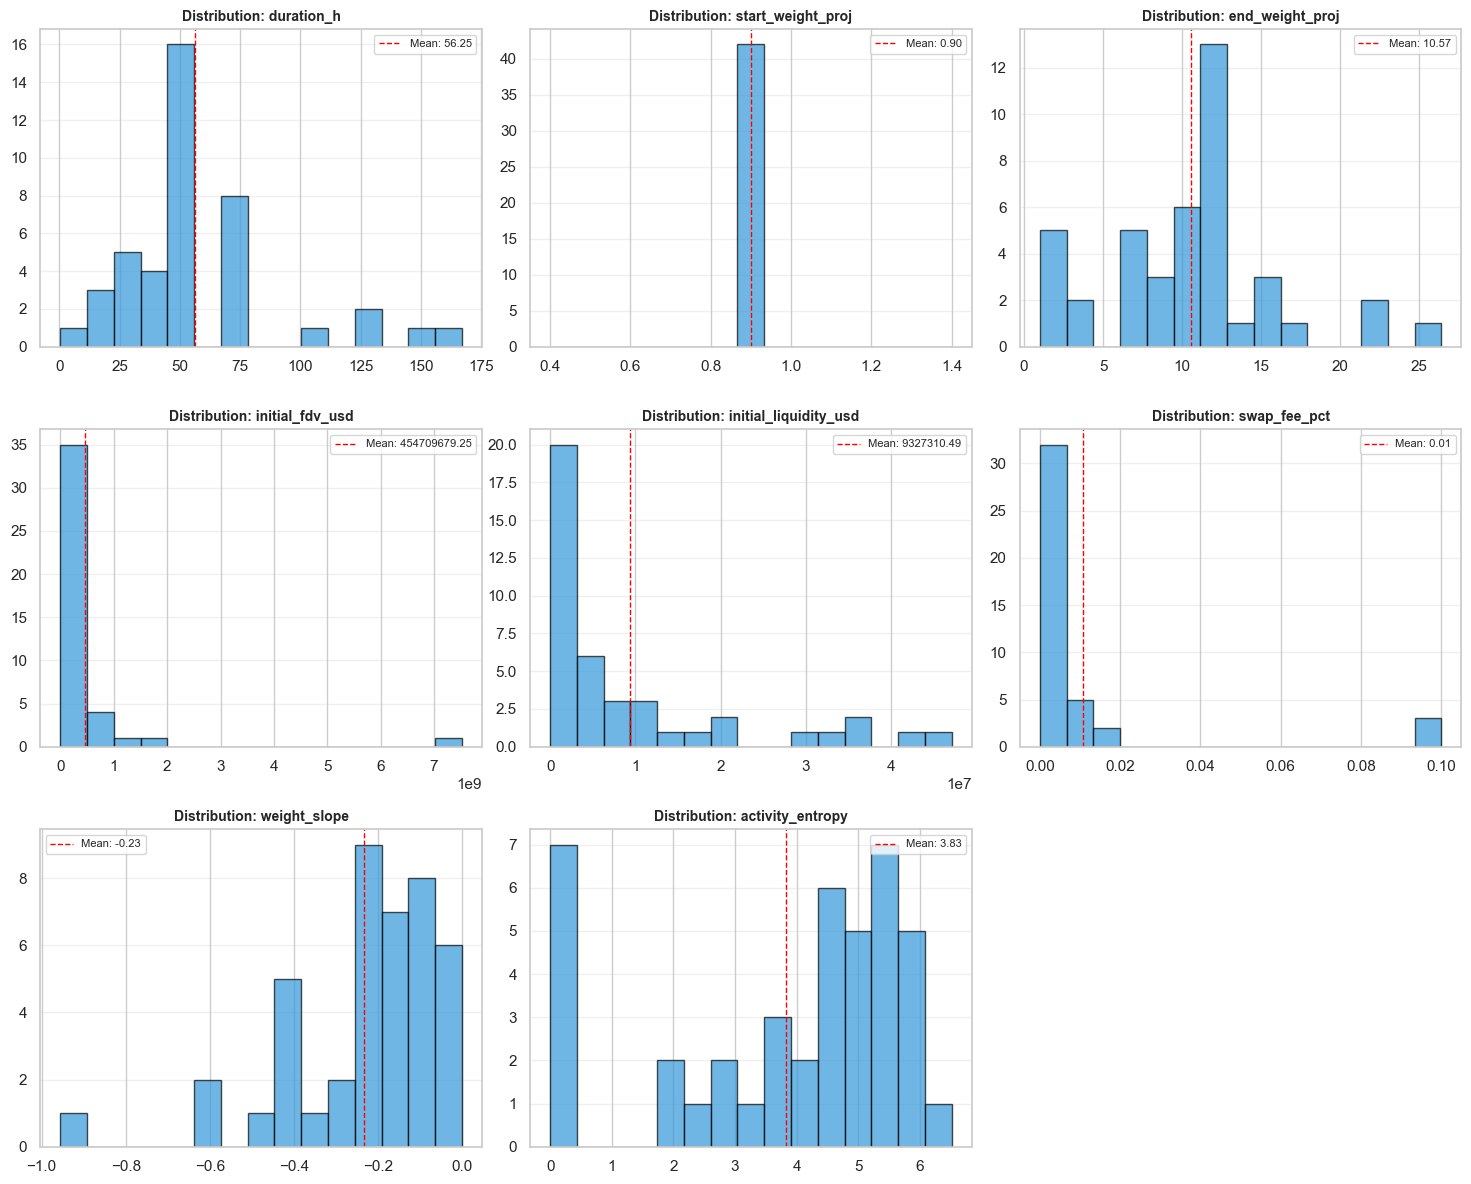

--- 3. Checking Feature Separation (Boxplots) ---


C:\Users\kaiqu\AppData\Local\Temp\ipykernel_20416\1874416690.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1], labels=['Fail (0)', 'Success (1)'],
C:\Users\kaiqu\AppData\Local\Temp\ipykernel_20416\1874416690.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1], labels=['Fail (0)', 'Success (1)'],
C:\Users\kaiqu\AppData\Local\Temp\ipykernel_20416\1874416690.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1], labels=['Fail (0)', 'Success (1)'],
C:\Users\kaiqu\AppData\Local\Temp\ipykernel_20416\1874416690.py:79: Matpl

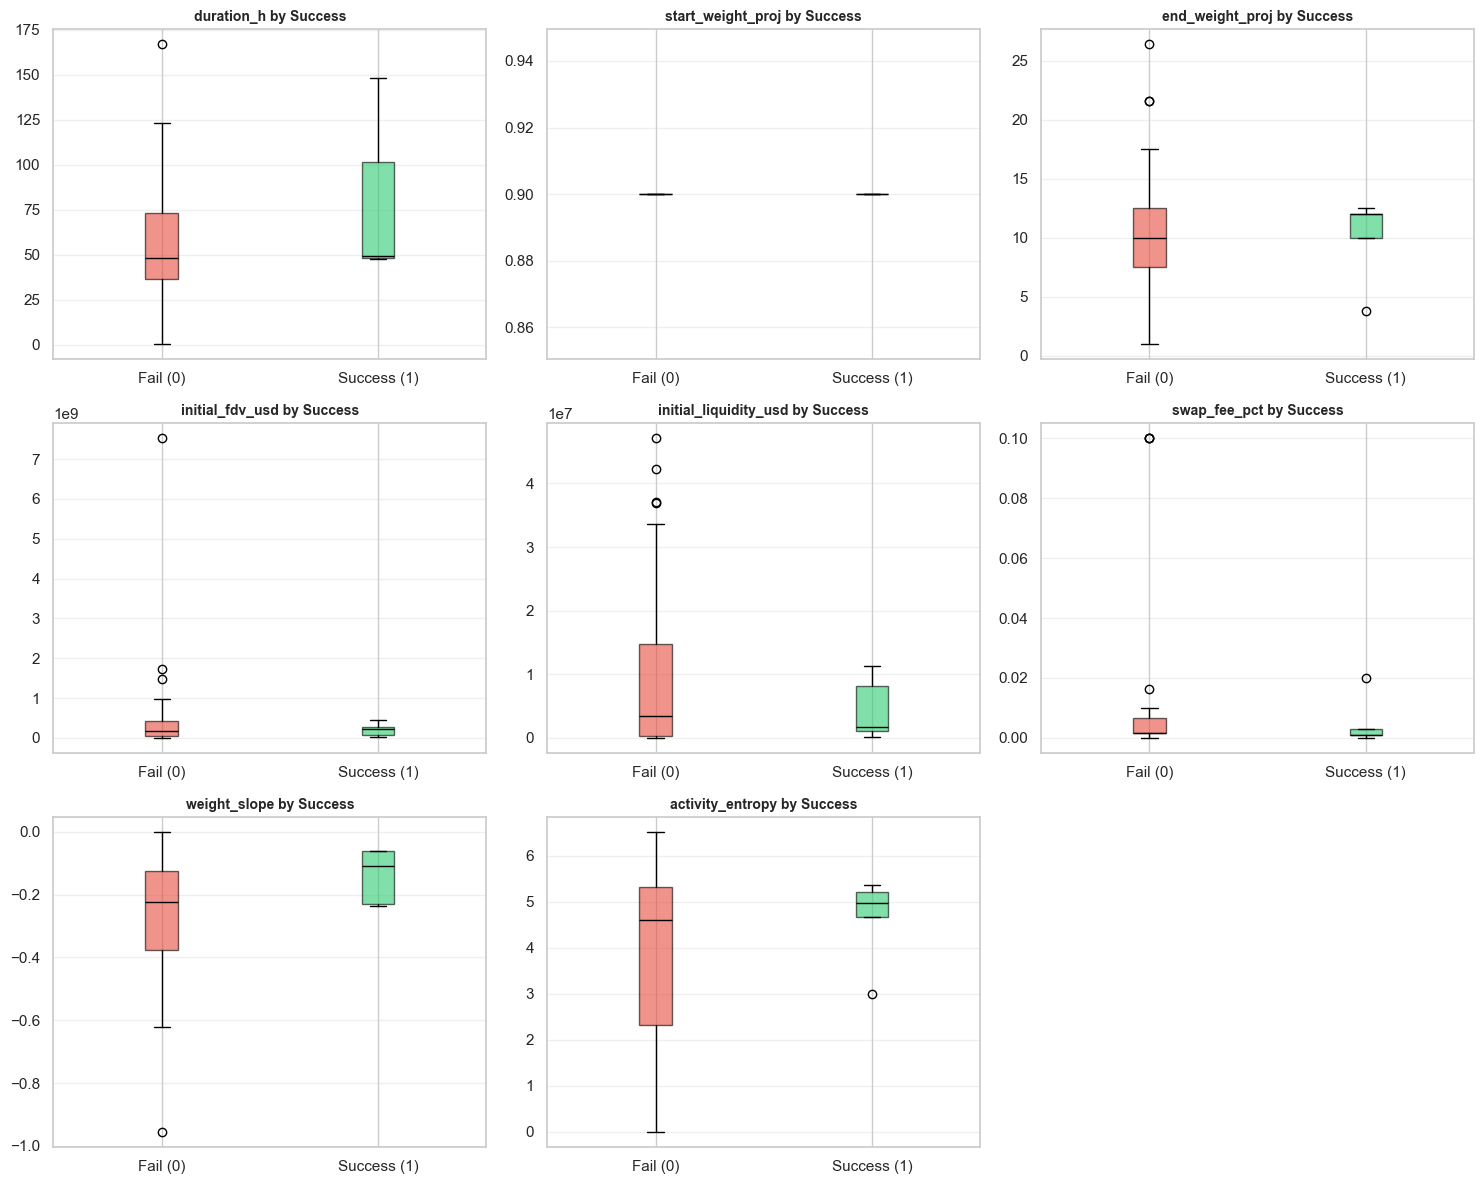

In [30]:
print("--- 1. Checking Class Balance ---")
plot_target_balance(v1_df_ready)

print("--- 2. Checking Numerical Distributions ---")
plot_numerical_distributions(v1_df_ready, numerical_features)

print("--- 3. Checking Feature Separation (Boxplots) ---")
plot_feature_vs_success(v1_df_ready, numerical_features)

--- 1. Checking Correlations ---


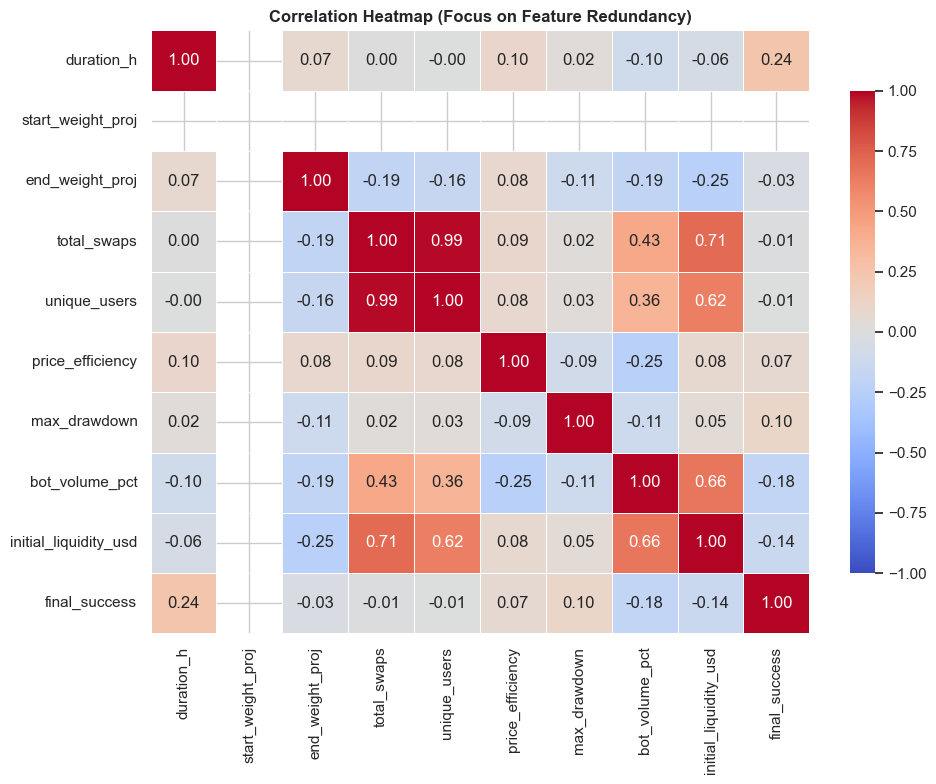

--- 2. Checking Bot Influence ---


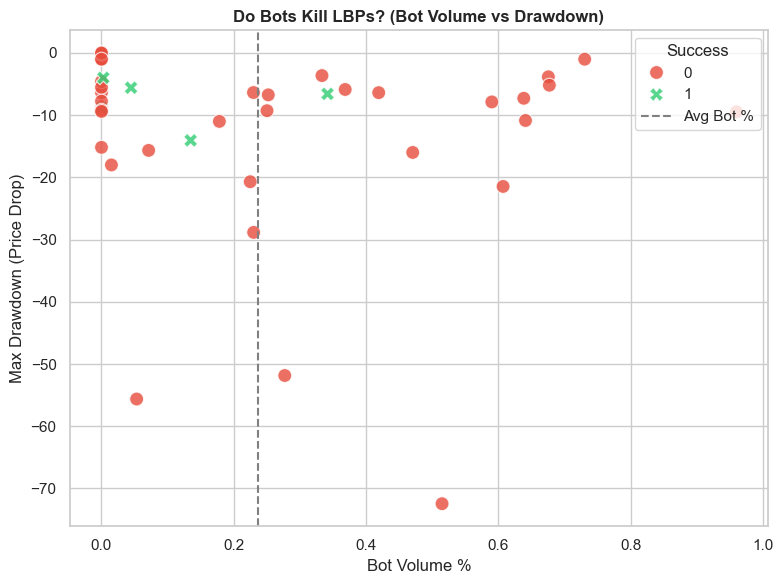

--- 3. Checking Build Parameters ---


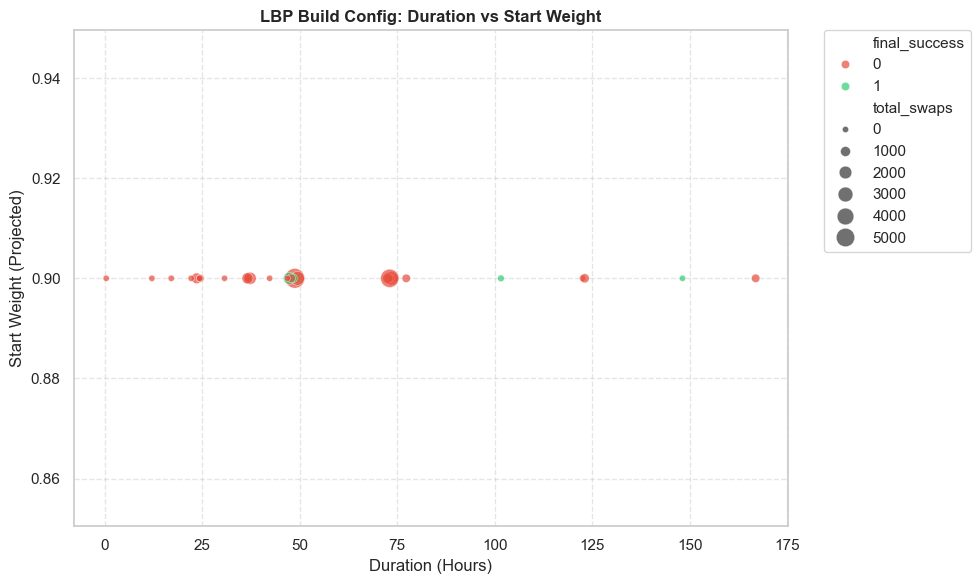

In [31]:
print("--- 1. Checking Correlations ---")
plot_correlation_matrix(v1_df_ready)

print("--- 2. Checking Bot Influence ---")
plot_bot_impact(v1_df_ready)

print("--- 3. Checking Build Parameters ---")
plot_config_landscape(v1_df_ready)

## Prepare dataset to ML training

In [28]:
# 1. Define your Input Features (X) - The 10 columns for the model
feature_cols = [
    'duration_h', 
    'start_weight_proj', 
    'end_weight_proj', 
    'weight_slope', 
    'initial_fdv_usd', 
    'initial_liquidity_usd', 
    'swap_fee_pct', 
    'collateral_is_stable', 
    'is_weekend', 
    'hour_of_day'
]

# 2. Define your Output Targets (y) - What you want to predict
target_cols = [
    'price_found_success', 
    'consistent_activity_success', 
    'not_bot_success', 
    'final_success'
]

# 3. Create the dedicated ML dataframe
v1_df_ml = v1_df_ready[feature_cols + target_cols].copy()

# 4. Final verification
print(f"Final ML Dataset Shape: {v1_df_ml.shape}")
print("-" * 30)
print("Input Features:", len(feature_cols))
print("Output Targets:", len(target_cols))
print("-" * 30)

# 5. Save to a new CSV file
v1_df_ml.to_csv('balancer_v1_ml_training_data.csv', index=False)

print("Success! File 'balancer_v1_ml_training_data.csv' created.")
v1_df_ml.head()

Final ML Dataset Shape: (42, 14)
------------------------------
Input Features: 10
Output Targets: 4
------------------------------
Success! File 'balancer_v1_ml_training_data.csv' created.


,duration_h,start_weight_proj,end_weight_proj,weight_slope,initial_fdv_usd,initial_liquidity_usd,swap_fee_pct,collateral_is_stable,is_weekend,hour_of_day,price_found_success,consistent_activity_success,not_bot_success,final_success
2,74.664444,0.9,17.50,-0.222328,1.024989e+07,1.123858e+05,0.0015,0,0,13,0,1,1,0
3,23.631111,0.9,11.25,-0.437982,1.613912e+08,9.634065e+06,0.0050,1,0,12,0,1,1,0
5,77.347500,0.9,12.50,-0.149973,9.623615e+08,9.472433e+06,0.0015,1,0,13,1,1,0,0
8,12.140833,0.9,12.50,-0.955453,1.772398e+08,2.418966e+05,0.0015,1,0,0,0,0,1,0
10,73.893611,0.9,1.00,-0.001353,3.861751e+02,3.031250e+02,0.0015,0,1,10,0,1,1,0


# V2

In [45]:
v2_df = pd.read_csv('../media/v2/FINAL_LBPs_BalancerV2.csv')
v2_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426 entries, 0 to 425
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   pool_id                426 non-null    object 
 1   launch_date            426 non-null    object 
 2   duration_h             426 non-null    float64
 3   start_weight_proj      426 non-null    float64
 4   end_weight_proj        426 non-null    float64
 5   total_swaps            426 non-null    int64  
 6   unique_users           426 non-null    int64  
 7   swaps_per_hour         426 non-null    float64
 8   activity_entropy       426 non-null    float64
 9   max_drawdown           426 non-null    float64
 10  price_efficiency       426 non-null    float64
 11  bot_volume_pct         426 non-null    float64
 12  initial_fdv_usd        426 non-null    float64
 13  buy_pressure_avg       426 non-null    float64
 14  peak_activity_time     426 non-null    float64
 15  weight

## Data distribution and cleaning

--- 1. Checking Class Balance ---


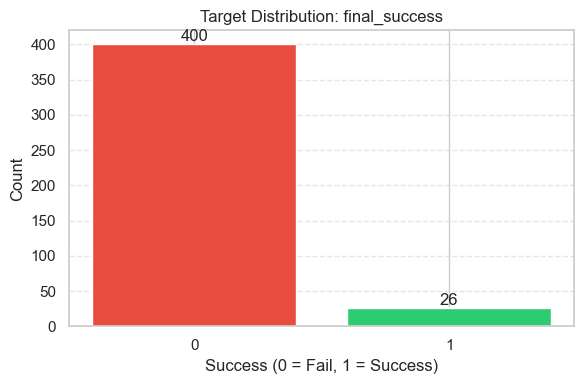

--- 2. Checking Numerical Distributions ---


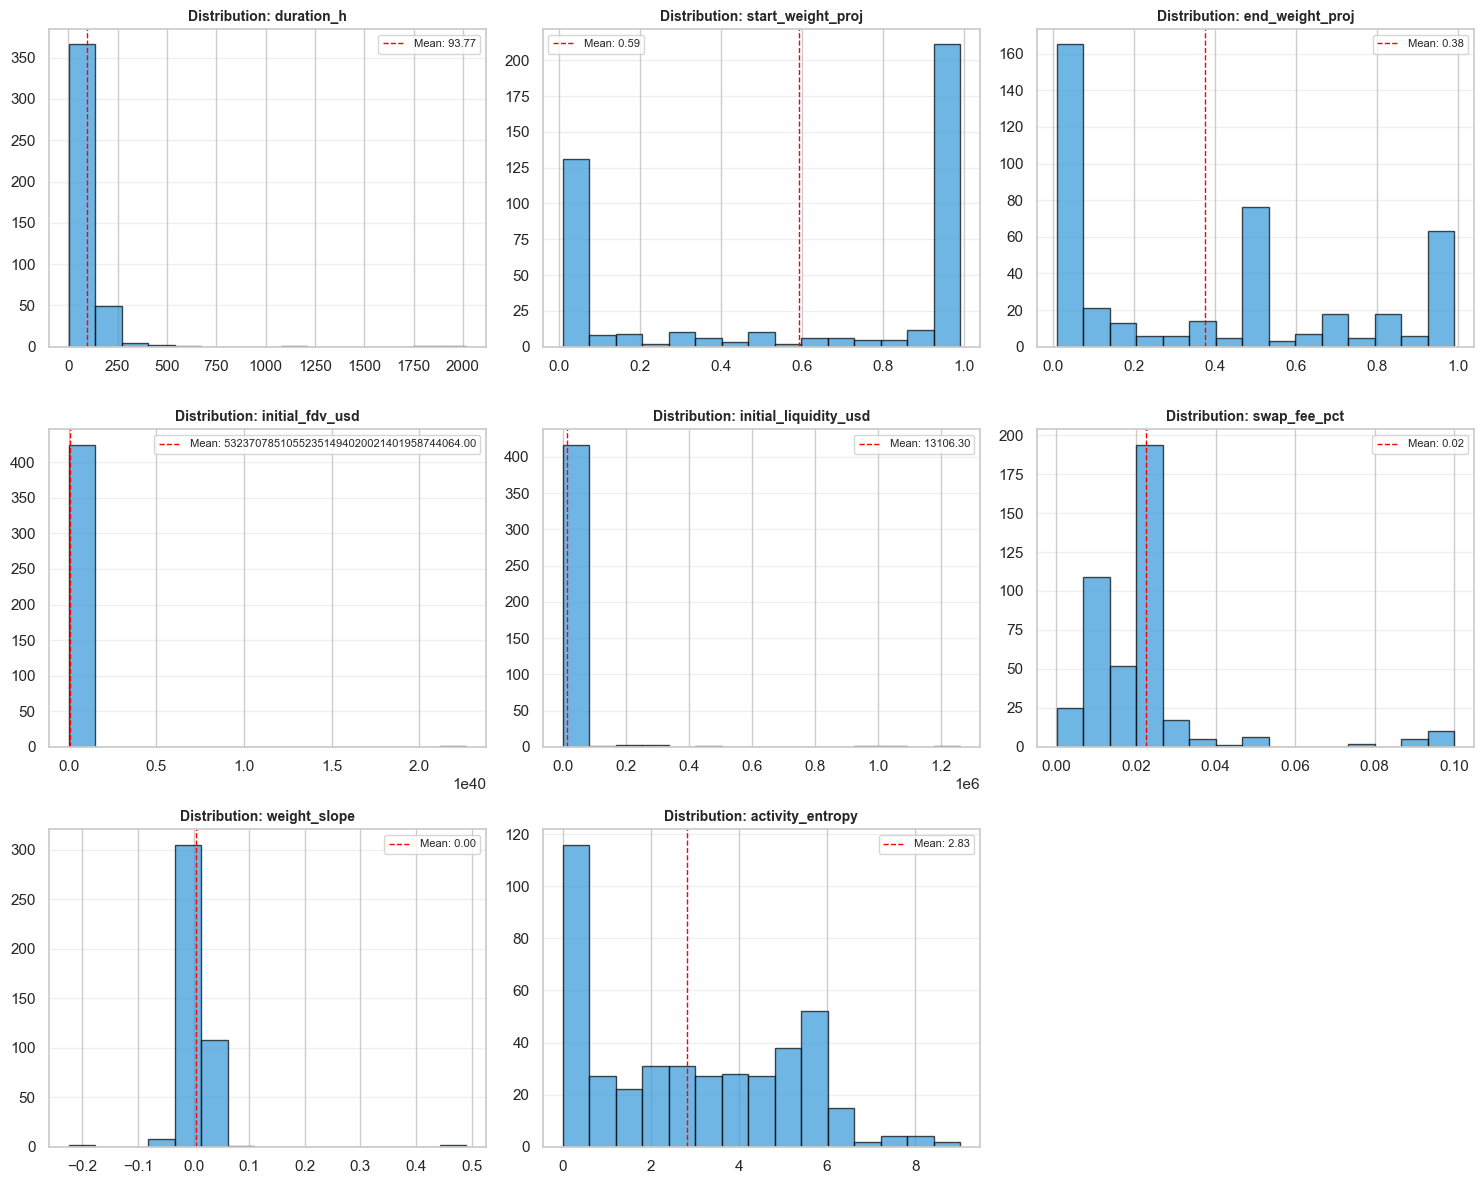

--- 3. Checking Feature Separation (Boxplots) ---


C:\Users\kaiqu\AppData\Local\Temp\ipykernel_20416\1874416690.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1], labels=['Fail (0)', 'Success (1)'],
C:\Users\kaiqu\AppData\Local\Temp\ipykernel_20416\1874416690.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1], labels=['Fail (0)', 'Success (1)'],
C:\Users\kaiqu\AppData\Local\Temp\ipykernel_20416\1874416690.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1], labels=['Fail (0)', 'Success (1)'],
C:\Users\kaiqu\AppData\Local\Temp\ipykernel_20416\1874416690.py:79: Matpl

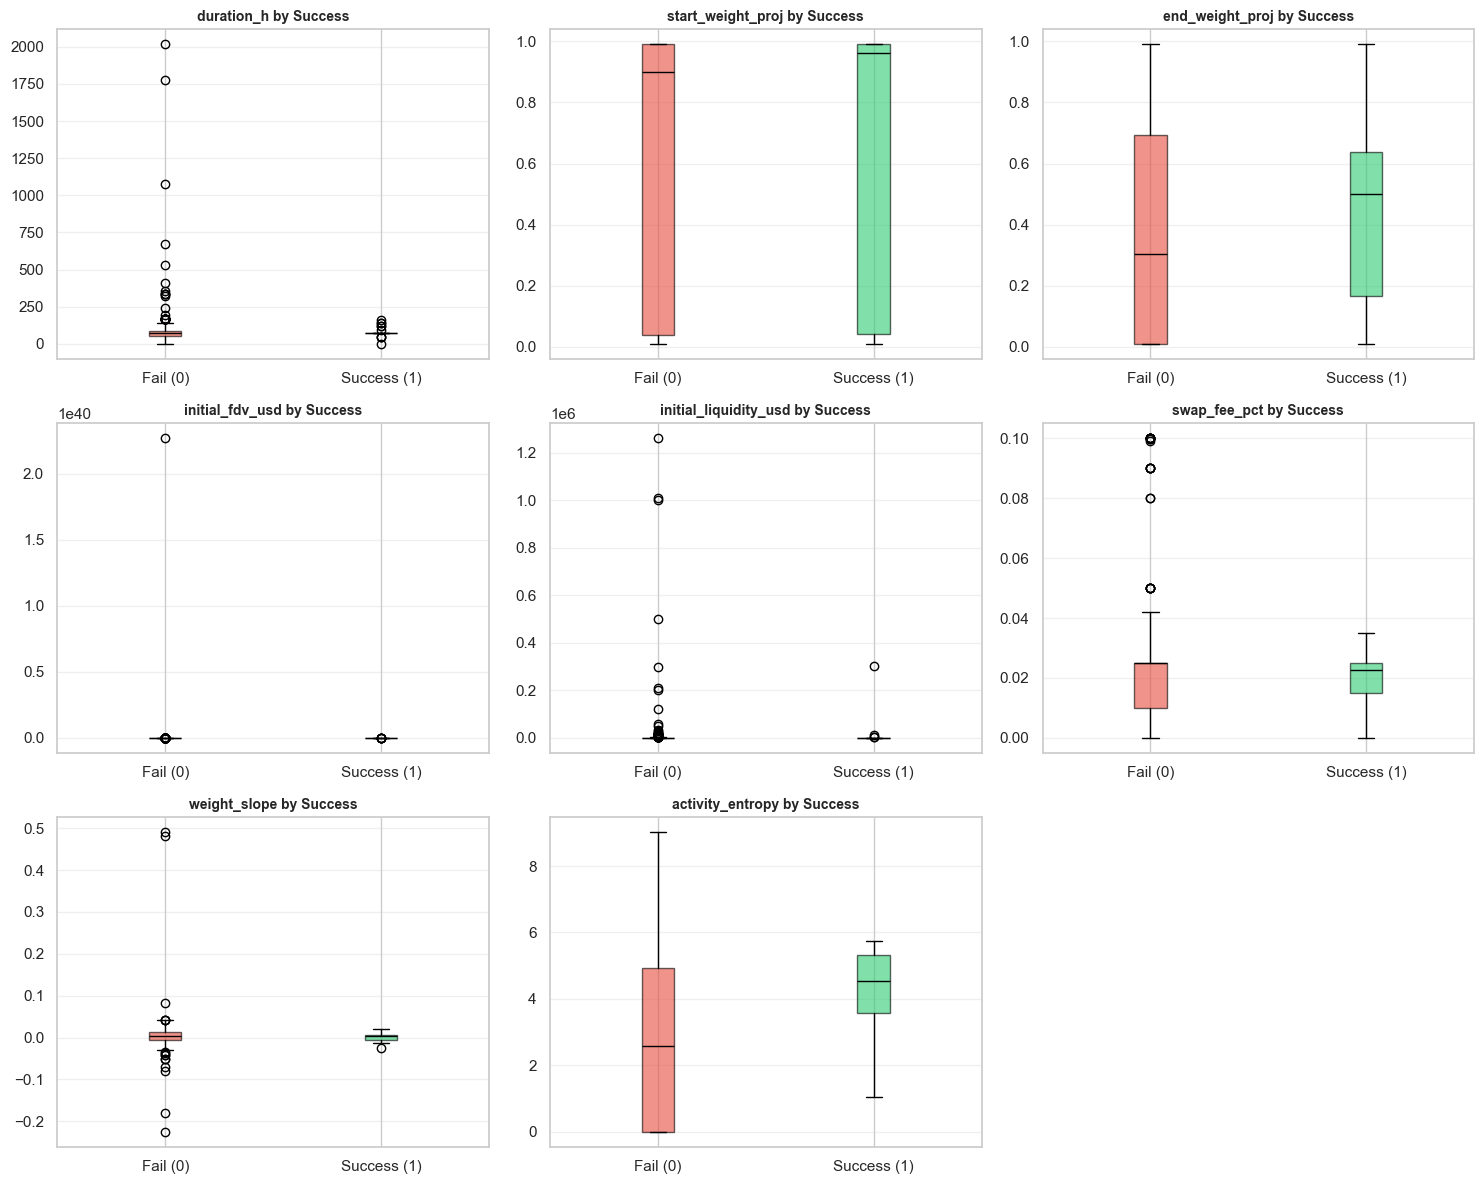

In [39]:
print("--- 1. Checking Class Balance ---")
plot_target_balance(v2_df)

print("--- 2. Checking Numerical Distributions ---")
plot_numerical_distributions(v2_df, numerical_features)

print("--- 3. Checking Feature Separation (Boxplots) ---")
plot_feature_vs_success(v2_df, numerical_features)

--- 1. Checking Correlations ---


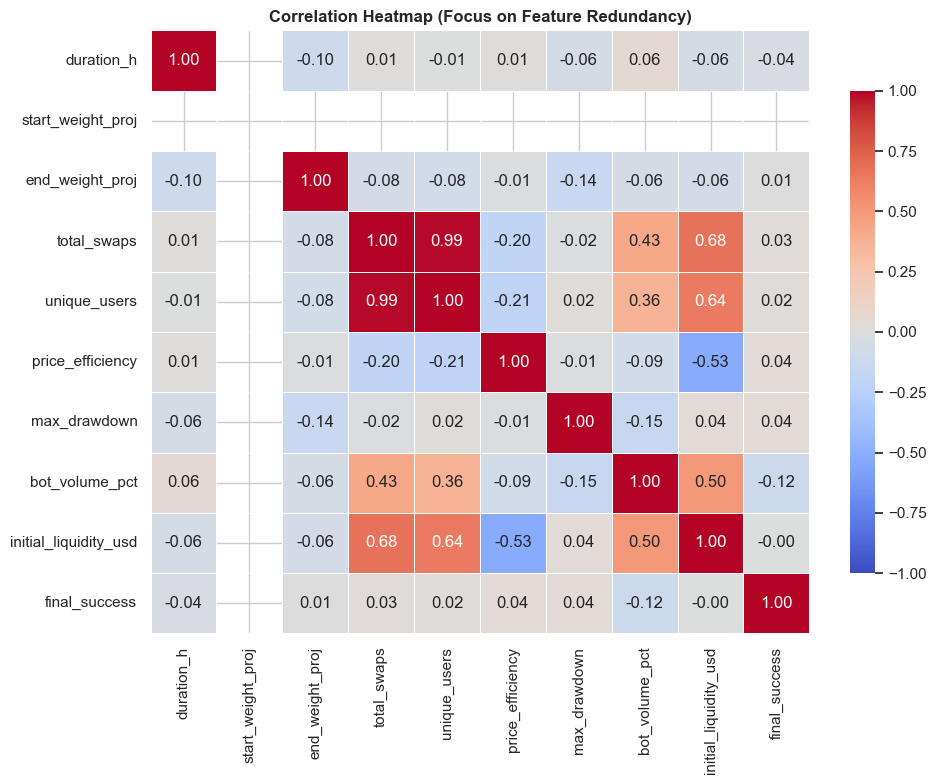

--- 2. Checking Bot Influence ---


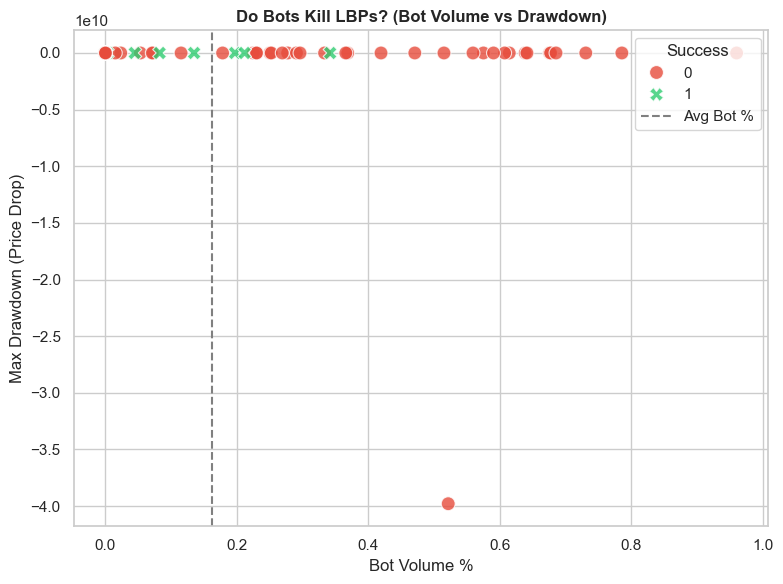

--- 3. Checking Build Parameters ---


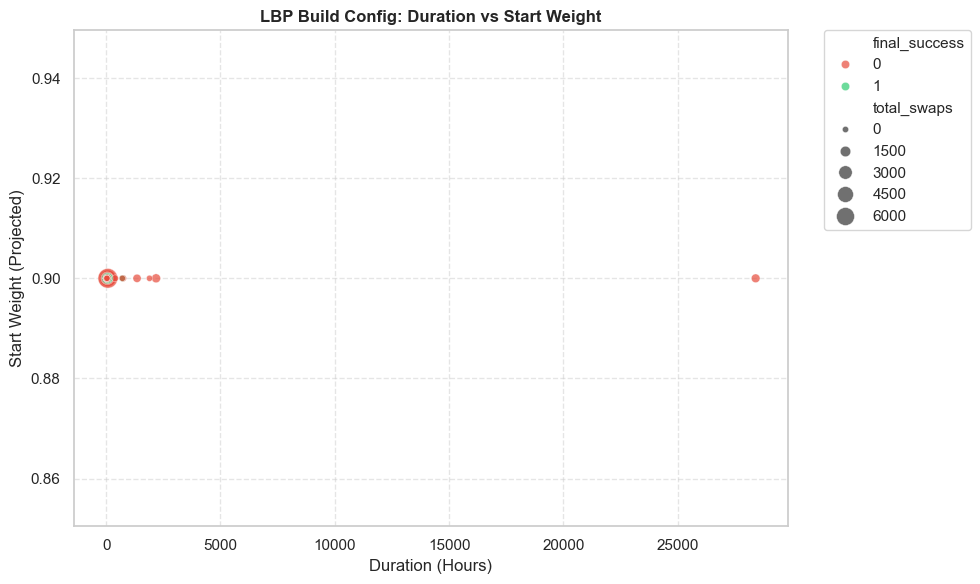

In [40]:
print("--- 1. Checking Correlations ---")
plot_correlation_matrix(v1_df)

print("--- 2. Checking Bot Influence ---")
plot_bot_impact(v1_df)

print("--- 3. Checking Build Parameters ---")
plot_config_landscape(v1_df)

In [46]:
# Create a filter for the "bad" liquidity rows
bad_data = v2_df[v2_df['initial_liquidity_usd'] <= 0]

print("--- Inspecting Negative Data ---")
print(bad_data[['pool_id', 'initial_liquidity_usd', 'initial_fdv_usd']].head(10))

print("\n--- Value Analysis ---")
print("Count of exactly -1:", len(bad_data[bad_data['initial_liquidity_usd'] == -1]))
print("Count of exactly  0:", len(bad_data[bad_data['initial_liquidity_usd'] == 0]))
print("Smallest negative value:", bad_data['initial_liquidity_usd'].min())

--- Inspecting Negative Data ---
                                              pool_id  initial_liquidity_usd  \
0   0xb37a8e9ceafa4a3636d6bcdb35ee1e94c20c78e00002...                    0.0   
1   0x0f22556c1035337391a5b0664190c6b8327327280002...                    0.0   
2   0x11cc00181680ffad62cce2771154a77e4c2a73cf0002...                    0.0   
4   0x94ce642f78ef731a3748dd058c084458af1b56300002...                    0.0   
6   0x8a97d99c58db4aee085de188983388b79ca7d9f00002...                    0.0   
11  0x40f1cb91325dd8ef24dfac085c9ba46ea309e5e20002...                    0.0   
13  0x7e8fd1b4dbdfedb682c23ec79618f6cb0d68d3360002...                    0.0   
14  0x753bd6a5bf0b14ae7e5d2877e5cd6a3398aa2aab0002...                    0.0   
20  0x0a336d1a947dc92855a228f653f71f6905729b270002...                    0.0   
21  0x80ba1773e82070c284907eaee2ba05453f14f0710002...                    0.0   

    initial_fdv_usd  
0      0.000000e+00  
1      0.000000e+00  
2      5.918544e+11 

In [43]:
v2_df_ready = strict_clean_data(v2_df)

Rows after removing non-positive durations: 426 (Removed 0)
Rows after removing non-positive FDV: 324 (Removed 102)
Rows after removing non-positive Liquidity: 124 (Removed 200)
--- 1. Sanity Check (Physical Rules) ---
Rows after removing impossible values (negatives/zeros): 124

--- 2. Statistical Cleaning (Threshold: 3.0) ---
Column 'duration_h': Found 4 outliers
Column 'weight_slope': Found 6 outliers
Column 'bot_volume_pct': Found 18 outliers
----------------------------------------
Original Rows: 426
Final Rows:    101
----------------------------------------
